# COE-292 Project

## Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers

## Data Loading & Pre-Processing

In [2]:
# Data loading

data_file_path = "sentiment_analysis.csv"

data = pd.read_csv (data_file_path)
data.head()

,Year,Month,Day,Time of Tweet,text,sentiment,Platform
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook
2,2017,8,18,night,Don't angry me,negative,Facebook
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram


In [3]:
# Specifying the features and target columns
features = data.columns.tolist()
features.remove('sentiment')

target = 'sentiment'

In [4]:
# Check for missing values in the features columns

# Determine which columns have missing values
missing_columns = data[features].isnull().any()
missing_columns = missing_columns[missing_columns].index.tolist()

# Fill missing values with the mean of the column
if missing_columns:
    for col in missing_columns:
        data[col].fillna(data[col].mean(), inplace=True)

In [5]:
# Check for missing values in the target column

missing_target = data[target].isnull().any()

# Fill missing values with the mean of the column
if missing_target:
    data[target].fillna(data[target].mean(), inplace=True)

In [6]:
# Check Inconsistencies in the features columns
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494 entries, 0 to 493
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           494 non-null    int64 
 1   Month          494 non-null    int64 
 2   Day            494 non-null    int64 
 3   Time of Tweet  494 non-null    object
 4   text           494 non-null    object
 5   sentiment      494 non-null    object
 6   Platform       494 non-null    object
dtypes: int64(3), object(4)
memory usage: 27.1+ KB


None

In [7]:
# Endcoding categorical columns without 'text' because we will use TfidfVectorizer on it
# Identifying object columns, but exclude 'text'
categorical_columns = [col for col in data.select_dtypes(include=['object']).columns
                       if col not in ['text']]

label_encoder = LabelEncoder()
for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

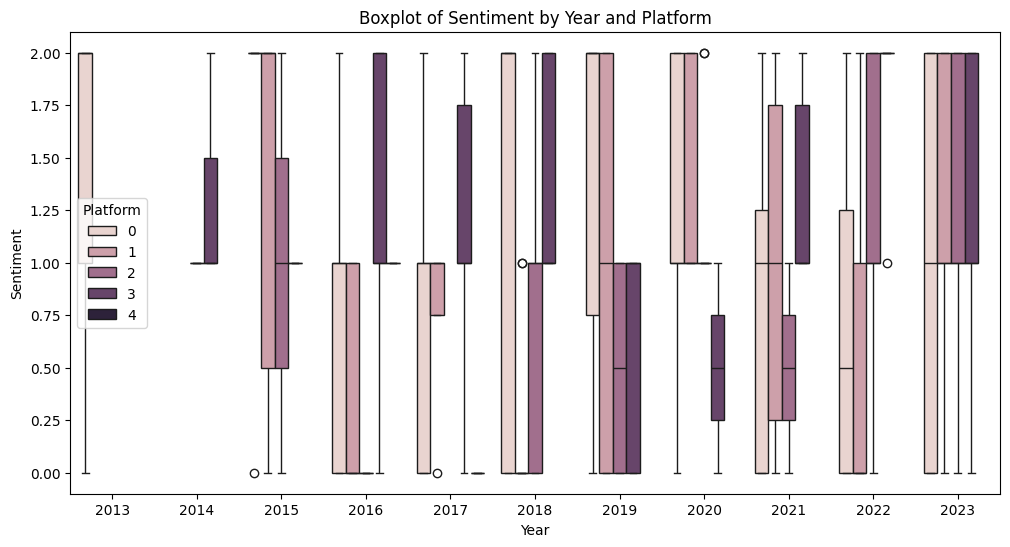

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='Year', y='sentiment', hue='Platform')
plt.title('Boxplot of Sentiment by Year and Platform')
plt.xlabel('Year')
plt.ylabel('Sentiment')
plt.legend(title='Platform')
plt.show()

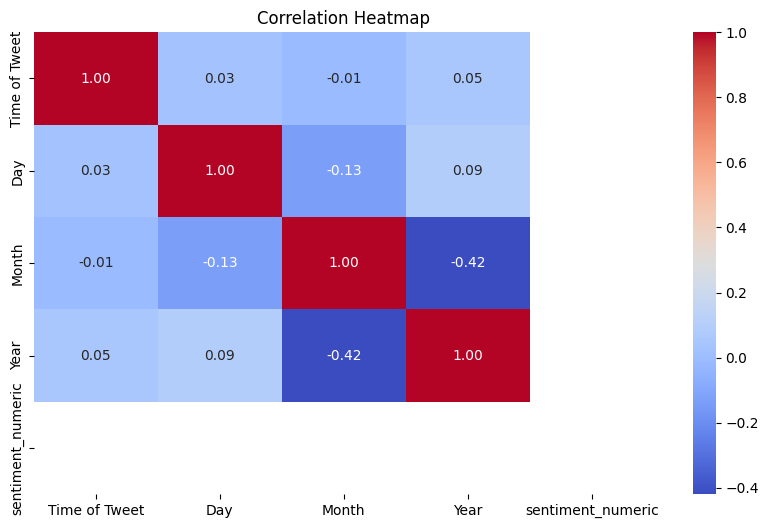

In [9]:
data['sentiment_numeric'] = data['sentiment'].map( {'positive':1,'neutral':0,' negative':-1})
corrMatrix = data[ ['Time of Tweet','Day', 'Month','Year','sentiment_numeric']  ].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corrMatrix, annot=True,cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

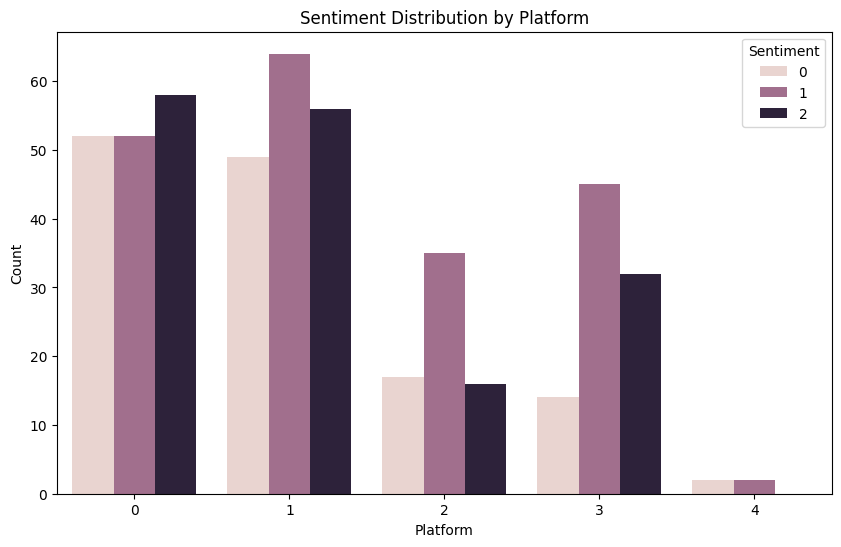

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Platform', hue='sentiment')
plt.title('Sentiment Distribution by Platform')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.show()

In [11]:
# Splitting the dataset into features (X) and target (y)

from sklearn.feature_extraction.text import TfidfVectorizer

# Converting the 'text' column to numeric features using TF-IDF encoding, because it includes sentneces
vectorizer = TfidfVectorizer()
text_features = vectorizer.fit_transform(data['text'].astype(str)).toarray()

# Extracting the remaining features (without the 'text' feature) and the target labels
other_features = data.drop(columns=['text', 'sentiment']).values
y = data['sentiment'].values

# Spliting the data into training and testing sets for each (text, other features, and labels)
other_train, other_test, y_train, y_test, text_train, text_test = train_test_split(other_features, y, text_features, test_size=0.3, random_state=42)

# Normalizing the features using StandardScaler, without the 'text' feature because it's being normalized by default when using the 'TfidfVectorizer'
scaler = StandardScaler()
other_train_scaled = scaler.fit_transform(other_train)
other_test_scaled = scaler.transform(other_test)

# Combining the scaled non-text features with the TF-IDF text features
X_train = np.hstack((text_train, other_train_scaled))
X_test = np.hstack((text_test, other_test_scaled))

from sklearn.impute import SimpleImputer

# Creating an imputer to fill missing values with the mean of each column, so we don't have Nan values
imputer = SimpleImputer(strategy='mean')

# Applying the imputer to both training and testing data
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [1385]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [1385]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


## KNN

### Euclidean Distance

In [12]:
acc_Euc=[]

Kvalues= range (1, 31)
# Calculating error for K values between 1 and 30
for k in Kvalues:
    knn = KNeighborsClassifier(n_neighbors=k, p=2)
# Euclidean Distance when p=2 (default), for Manhatten Distance p=1
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    acc_Euc.append(accuracy)

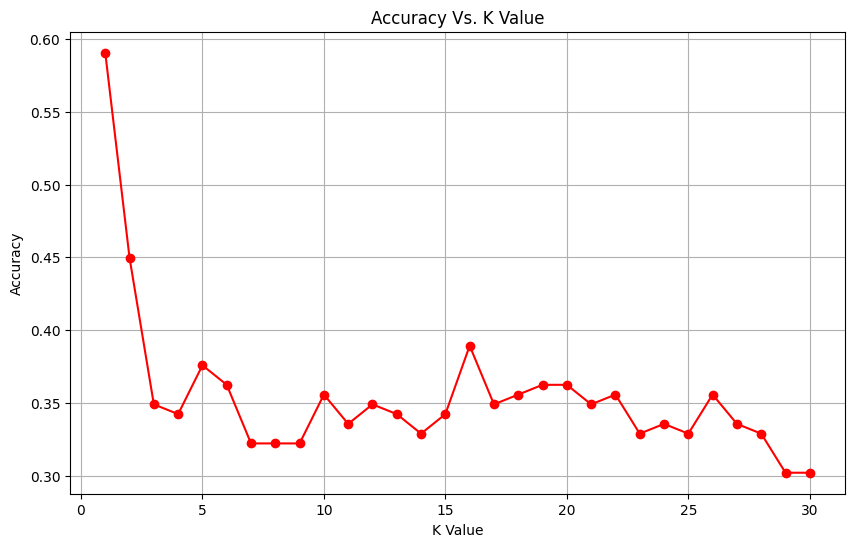

1


In [13]:
# Plot accuracy VS K values
plt.figure(figsize=(10, 6))
plt.plot(Kvalues, acc_Euc, color='red', marker='o')
plt.title('Accuracy Vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Find the best K value
bestK= Kvalues[np.argmax(acc_Euc)]
print (bestK)

In [14]:
# Fit the final model with the best K value
bestKnn= KNeighborsClassifier(n_neighbors=bestK)
bestKnn.fit(X_train, y_train)
y_pred_bestEuc= bestKnn.predict(X_test)

### Manhatten Distance

In [15]:
acc_Mn=[]

Kvalues= range (1, 31)
# Calculating error for K values between 1 and 30
for k in Kvalues:
    knnMn = KNeighborsClassifier(n_neighbors=k, p=1)
# Euclidean Distance when p=2 (default), for Manhatten Distance p=1
    knnMn.fit(X_train, y_train)
    y_pred = knnMn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    acc_Mn.append(accuracy)

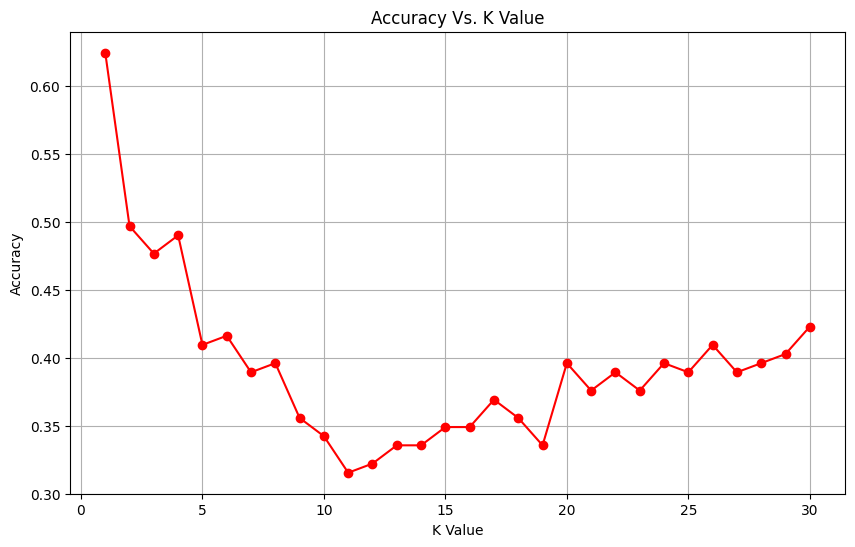

1


In [16]:
# Plot accuracy VS K values
plt.figure(figsize=(10, 6))
plt.plot(Kvalues, acc_Mn, color='red', marker='o')
plt.title('Accuracy Vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Find the best K value
bestKmn= Kvalues[np.argmax(acc_Mn)]
print (bestKmn)

In [17]:
# Fit the final model with the best K value
best_KnnMn= KNeighborsClassifier(n_neighbors=bestKmn)
best_KnnMn.fit(X_train, y_train)
y_pred_bestMn= best_KnnMn.predict(X_test)

### KNN Evaluation

In [18]:
# Generate Confusion Matrix and Print The R esults
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix: \n{conf_matrix}")

Confusion Matrix: 
[[10 29  3]
 [11 37 10]
 [12 21 16]]


In [19]:
# Calculate Accuracy, Prsision, and Recall
# For Euclidean Distance
accuracy_Euc= accuracy_score(y_test, y_pred_bestEuc)
Presision_Euc=precision_score(y_test, y_pred_bestEuc, average='macro')
Recall_Euc=recall_score(y_test, y_pred_bestEuc, average='macro')
# For Manhatten Distance
accuracy_Mn= accuracy_score(y_test, y_pred_bestMn)
Presision_Mn=precision_score(y_test, y_pred_bestMn, average='macro')
Recall_Mn=recall_score(y_test, y_pred_bestMn, average='macro')

print('For Euclidean Distance:')
print('Accuracy:',accuracy_Euc*100,"%")
print('Prsision:',Presision_Euc*100,"%")
print('Recall:',Recall_Euc*100,"%")
print("="*100)
print('For Manhatten Distance:')
print('Accuracy:',accuracy_Mn*100,"%")
print('Prsision:',Presision_Mn*100,"%")
print('Recall:',Recall_Mn*100,"%")

For Euclidean Distance:
Accuracy: 59.06040268456376 %
Prsision: 58.724133775893606 %
Recall: 58.890452732817266 %
For Manhatten Distance:
Accuracy: 59.06040268456376 %
Prsision: 58.724133775893606 %
Recall: 58.890452732817266 %


In [20]:
# Calculate Cross-Validated Accuracy, Prsision, and Recall
# For Euclidean Distance
Kfold = KFold(n_splits=10, random_state=1234, shuffle=True)
CVaccuracy_Euc = np.round(np.mean(cross_val_score(bestKnn, X_train, y_train, cv=Kfold, scoring='accuracy')),2)
CVpresision_Euc = np.round(np.mean(cross_val_score(bestKnn, X_train, y_train, cv=Kfold, scoring='precision_macro')),2)
CVrecall_Euc = np.round(np.mean(cross_val_score(bestKnn, X_train, y_train, cv=Kfold, scoring='recall_macro')),2)
print('For Euclidean Distance:')
print('Cross-Validated Accuracy:',CVaccuracy_Euc*100,"%")
print('Cross-Validated Prsision:',CVpresision_Euc*100,"%")
print('Cross-Validated Recall:',CVrecall_Euc*100,"%")
print("="*100)
CVaccuracy_Mn= np.round(np.mean(cross_val_score(bestKnn, X_train, y_train, cv=Kfold, scoring='accuracy')),2)
CVpresision_Mn = np.round(np.mean(cross_val_score(bestKnn, X_train, y_train, cv=Kfold, scoring='precision_macro')),2)
CVrecall_Mn = np.round(np.mean(cross_val_score(bestKnn, X_train, y_train, cv=Kfold, scoring='recall_macro')),2)
print('For Manhatten Distance:')
print('Cross-Validated Accuracy:',CVaccuracy_Mn*100,"%")
print('Cross-Validated Prsision:',CVpresision_Mn*100,"%")
print('Cross-Validated Recall:',CVrecall_Mn*100,"%")

For Euclidean Distance:
Cross-Validated Accuracy: 57.99999999999999 %
Cross-Validated Prsision: 56.00000000000001 %
Cross-Validated Recall: 57.99999999999999 %
For Manhatten Distance:
Cross-Validated Accuracy: 57.99999999999999 %
Cross-Validated Prsision: 56.00000000000001 %
Cross-Validated Recall: 57.99999999999999 %


## SVM  hard-soft margin

Soft SVM confusion matrix is:
Classification report for classifier SVC():
              precision    recall  f1-score   support

           0       0.37      0.31      0.34        42
           1       0.45      0.53      0.49        58
           2       0.47      0.43      0.45        49

    accuracy                           0.44       149
   macro avg       0.43      0.42      0.42       149
weighted avg       0.43      0.44      0.43       149




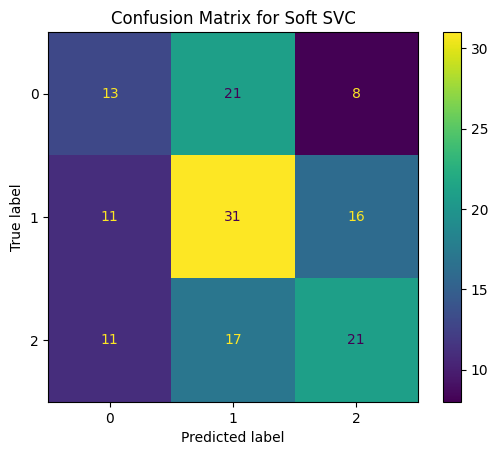

Accuracy = 43.62 %
Precision = 43.31 %
Recall = 43.62 %
Hard SVM confusion matrix is:
Classification report for classifier SVC(C=100):
              precision    recall  f1-score   support

           0       0.45      0.45      0.45        42
           1       0.54      0.53      0.54        58
           2       0.58      0.59      0.59        49

    accuracy                           0.53       149
   macro avg       0.53      0.53      0.53       149
weighted avg       0.53      0.53      0.53       149




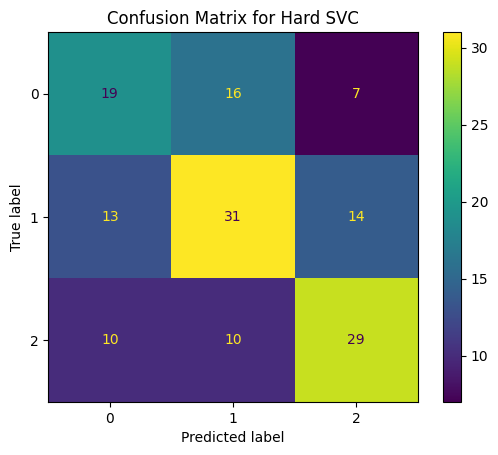

Accuracy = 53.02 %
Precision = 53.0 %
Recall = 53.02 %


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay


# Soft margin SVM
soft_svc = SVC(C=1.0, kernel='rbf')
soft_svc.fit(X_train, y_train)
y_pred = soft_svc.predict(X_test)  #
print('Soft SVM confusion matrix is:')

print(f"Classification report for classifier {soft_svc}:\n"
      f"{classification_report(y_test, y_pred)}\n")


conf_matrix_soft = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_soft, display_labels=soft_svc.classes_)
disp.plot()
disp.ax_.set_title("Confusion Matrix for Soft SVC")
plt.show()



print("Accuracy =", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("Precision =", round(precision_score(y_test, y_pred, average='weighted') * 100, 2), "%")
print("Recall =", round(recall_score(y_test, y_pred, average='weighted') * 100, 2), "%")


# Hard margin SVM
hard_svc = SVC(C=100, kernel='rbf')
hard_svc.fit(X_train, y_train)
y_pred = hard_svc.predict(X_test)
print('Hard SVM confusion matrix is:')

print(f"Classification report for classifier {hard_svc}:\n"
      f"{classification_report(y_test, y_pred)}\n")


conf_matrix_hard = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(conf_matrix_hard, display_labels=hard_svc.classes_)
disp.plot()
disp.ax_.set_title("Confusion Matrix for Hard SVC")
plt.show()

print("Accuracy =", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("Precision =", round(precision_score(y_test, y_pred, average='weighted') * 100, 2), "%")
print("Recall =", round(recall_score(y_test, y_pred, average='weighted') * 100, 2), "%")

In [22]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.svm import SVC
import numpy as np

kf = KFold(n_splits=10, random_state=1234, shuffle=True)

# HARD MARGIN

hard_CVaccuracy = np.round(np.mean(cross_val_score(hard_svc, X_train, y_train, cv=Kfold, scoring='accuracy')),2)
hard_CVpresision= np.round(np.mean(cross_val_score(hard_svc, X_train, y_train, cv=Kfold, scoring='precision_macro')),2)
hard_CVrecall = np.round(np.mean(cross_val_score(hard_svc, X_train, y_train, cv=Kfold, scoring='recall_macro')),2)
print('For hard margin SVM')
print('Cross-Validated Accuracy:',hard_CVaccuracy*100,"%")
print('Cross-Validated Prsision:',hard_CVpresision*100,"%")
print('Cross-Validated Recall:',hard_CVrecall*100,"%")

# SOFT MARGIN


soft_CVaccuracy = np.round(np.mean(cross_val_score(soft_svc, X_train, y_train, cv=Kfold, scoring='accuracy')), 2)
soft_CVprecision = np.round(np.mean(cross_val_score(soft_svc, X_train, y_train, cv=Kfold, scoring='precision_macro')), 2)
soft_CVrecall = np.round(np.mean(cross_val_score(soft_svc, X_train, y_train, cv=Kfold, scoring='recall_macro')), 2)

print('For soft margin SVM')
print('Cross-Validated Accuracy:', soft_CVaccuracy * 100, "%")
print('Cross-Validated Precision:', soft_CVprecision * 100, "%")
print('Cross-Validated Recall:', soft_CVrecall * 100, "%")

For hard margin SVM
Cross-Validated Accuracy: 57.99999999999999 %
Cross-Validated Prsision: 56.99999999999999 %
Cross-Validated Recall: 57.99999999999999 %
For soft margin SVM
Cross-Validated Accuracy: 49.0 %
Cross-Validated Precision: 51.0 %
Cross-Validated Recall: 48.0 %


### Deep Neural Network (DNN)

#### Implementation

In [23]:
# Getting out input data shape
input_shape = X_train.shape[1]
print("Input shape:", input_shape)

# Getting output shape number of uique classes
num_classes = len(np.unique(y_train))
print("Output shape:", num_classes)

Input shape: 1385
Output shape: 3


In [24]:
# Create a neural network
from keras.layers import Dense
from keras.models import Sequential
from keras.optimizers import Adam

DNN_model = Sequential()


# Add a hidden layer with 16 neruon, with ReLU activation
DNN_model.add(Dense(16, input_shape=(input_shape,), activation="relu"))

# Add a hidden layer with 32 neruon, with ReLU activation
DNN_model.add(Dense(32,  activation="relu"))

# Add output layer with the 'number of classes' neurons, with softmax activation
DNN_model.add(Dense(num_classes, activation="softmax"))

# Using an optimizer with 0.0005
optimizer = Adam(learning_rate=0.0005)

# SparseCategoricalCrossentropy is used when there are two or more label classes Labels must integers; label encoding
DNN_model.compile(
    optimizer=optimizer,
    loss="SparseCategoricalCrossentropy",   # we have 3 classes encoded with label encoding so we use SparseCategoricalCrossentropy
    metrics=["accuracy"]
)

DNN_model.fit(X_train, y_train, epochs=30, batch_size=30)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3735 - loss: 1.0953
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4308 - loss: 1.0866
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4121 - loss: 1.0811
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3946 - loss: 1.0754
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4245 - loss: 1.0604
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4293 - loss: 1.0491
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4317 - loss: 1.0362
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4484 - loss: 1.0286
Epoch 9/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4532 - loss: 1.0062 
Epoch 10/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4662 - loss: 0.9913
Epoch 11/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4655 - loss: 0.9897
Epoch 12/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy:

#### Evaluation

In [25]:
# Get predicted probabilities
pred_probs = DNN_model.predict(X_test)

# Convert probabilities to class labels (argmax selects the highest probability class)
y_pred_DNN = np.argmax(pred_probs, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [26]:
# Computing the confusion matrix and metrics
conf_matrix = confusion_matrix(y_test, y_pred_DNN)
acc_score = accuracy_score(y_test, y_pred_DNN)
prec_score = precision_score(y_test, y_pred_DNN, average='weighted')
rec_score = recall_score(y_test, y_pred_DNN, average='weighted')

# printing the corrected confusion matrix and metrics
print("Confusion Matrix:")
print(conf_matrix)
print("Accuracy:", acc_score)
print("Precision:", prec_score)
print("Recall:", rec_score)

Confusion Matrix:
[[16 22  4]
 [ 3 52  3]
 [ 9 10 30]]
Accuracy: 0.6577181208053692
Precision: 0.6686878633187359
Recall: 0.6577181208053692
